<a href="https://colab.research.google.com/github/Harsh-2404/Goldman-Sachs-Financial-Risk-Analysis/blob/main/Goldman_Financial_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Risk Analysis with Python - Goldman Sachs

## Project Objective

The objective of this project is to analyze customer financial transaction data to identify transaction trends, customer behavior, account performance, and potential financial risks using Python-based data analysis techniques.

In [ ]:
# Import Libraries

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and Time Handling
import datetime as dt

# Statistical Analysis / Hypothesis Testing
from scipy import stats

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("goldman_sachs.csv")

df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


In [ ]:
df.shape

(800, 15)

In [ ]:
# It Checks:
#  1.column name
#  2.datatype
#  3.missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [ ]:
# It evaluates count, mean, min, max of numerical columns:

df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,98.401250,51575.671765,72345.657910,0.473415,566.586250,126.58250
std,56.292618,29055.838886,34070.038539,0.242858,151.674261,68.98532
min,1.000000,-30721.247890,-37293.600250,-0.389354,305.000000,6.00000
25%,50.000000,31692.004800,49157.502723,0.313286,436.500000,65.00000
50%,97.000000,50249.069385,72789.370195,0.472155,563.000000,132.00000
75%,146.000000,71913.394570,95352.455698,0.636848,696.000000,186.25000
max,199.000000,130726.914100,175247.539500,1.163728,849.000000,239.00000


In [ ]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [ ]:
# Missing Values Check

df.isnull().sum()

,0
TransactionID,0
CustomerID,0
AccountID,0
AccountType,0
TransactionType,0
Product,0
Firm,0
Region,0
Manager,0
TransactionDate,0


**Observation**

No missing values were found in the dataset.

Therefore, no missing value treatment was required.

In [ ]:
# Duplicate Records Check

df.duplicated().sum()

np.int64(0)

**Observation**

No duplicate records were found.

Therefore, no duplicate removal was required.

### **Task 1: Data Cleaning and Formatting**

***1.1: Remove/treat any special characters or non-numeric entries from financial fields.***

In [ ]:
# Remove/treat any special characters or non-numeric entries from financial fields.

# Financial columns are: TransactionAmount and AccountBalance

# Check:

df[['TransactionAmount', 'AccountBalance']].head()

,TransactionAmount,AccountBalance
0,87480.05448,74008.43310
1,20315.74505,22715.83590
2,10484.57165,42706.09210
3,45122.27373,114176.56870
4,42360.79878,17863.02644


####**Observation:**
No special characters or invalid entries were found.

***1.2: Convert currency amounts into numerical format.***

In [ ]:
# Convert currency amounts into numerical format.

# Check:

df[['TransactionAmount', 'AccountBalance']].dtypes

,0
TransactionAmount,float64
AccountBalance,float64


#### **Observation:**
Both columns were already stored in numeric (`float64`) format, therefore no cleaning was required.

***1.3: Validate and format date columns.***

In [ ]:
# Validate and format date columns.

# Check:

df['TransactionDate'].dtype

dtype('O')

In [ ]:
# Convert date columns into datetime format

df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    errors='coerce'
)

In [ ]:
# Check again

df['TransactionDate'].dtype

dtype('<M8[ns]')

In [ ]:
df['TransactionDate'].head()

,TransactionDate
0,2023-10-21
1,2023-06-20
2,2023-01-02
3,2023-07-25
4,2023-07-25


***1.4: Ensure account types and transaction categories are standardized.***

In [ ]:
# Ensure account types and transaction categories are standardized.

# Account Type Standardization

df['AccountType'].unique()

array(['Credit', 'Current', 'Savings', 'Loan'], dtype=object)

In [ ]:
# Transaction Category Standardization

df['TransactionType'].unique()

array(['Withdrawal', 'Deposit', 'Payment', 'Transfer'], dtype=object)

**Observation**

The `AccountType` and `TransactionType` columns were inspected for inconsistent values such as extra spaces, different letter cases, and spelling variations.

No inconsistencies were found. Both columns were already standardized, so no additional cleaning was required.

### **Download** "clean_goldman_sachs.csv" **file from Google Colab**

In [ ]:
clean_df = df.copy()

clean_df.to_csv(
    "clean_goldman_sachs.csv",
    index=False
)

In [ ]:
from google.colab import files

In [ ]:
files.download("clean_goldman_sachs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Task 1 Conclusion

- The dataset was successfully inspected and prepared for further analysis.

- No missing values or duplicate records were found.

- Financial columns were already stored in numeric format.

- Transaction dates were converted into datetime format.

- Categorical variables were already standardized.

- The cleaned dataset is now ready for descriptive analysis.

### **Task 2: Descriptive Transactional Analysis**

***2.1: Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.***

In [ ]:
# Load cleaned dataset

df = pd.read_csv("clean_goldman_sachs.csv")

In [ ]:
# Convert TransactionDate into datetime

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [ ]:
# Check again

df['TransactionDate'].head()

,TransactionDate
0,2023-10-21
1,2023-06-20
2,2023-01-02
3,2023-07-25
4,2023-07-25


Step 1: Create Month and Year Columns

In [ ]:
# Step 1: Create Month and Year Columns

df["Month"] = df['TransactionDate'].dt.to_period("M")

df["Year"] = df['TransactionDate'].dt.year

df[['TransactionDate', "Month", "Year"]].head()

,TransactionDate,Month,Year
0,2023-10-21,2023-10,2023
1,2023-06-20,2023-06,2023
2,2023-01-02,2023-01,2023
3,2023-07-25,2023-07,2023
4,2023-07-25,2023-07,2023


Step 2: Separate Credit and Debit Transactions

In [ ]:
# Credit Transactions
credit = df[df['TransactionType'] == "Deposit"]

# Debit Transactions
debit = df[df['TransactionType'].isin(["Withdrawal", "Payment", "Transfer"])]

Step 3: Monthly Summary

In [ ]:
# Monthly Credit
monthly_credit = credit.groupby("Month")["TransactionAmount"].sum()

# Monthly Debit
monthly_debit = debit.groupby("Month")["TransactionAmount"].sum()

# Combine Credit and Debit
monthly_summary = pd.concat([monthly_credit, monthly_debit], axis=1)

# Rename Columns
monthly_summary.columns = ["Total Credit", "Total Debit"]

# Net Transactions Valume
monthly_summary["Net Transactions"] = (
    monthly_summary["Total Credit"] - monthly_summary["Total Debit"]
)

# Round Values
monthly_summary = monthly_summary.round(2)

monthly_summary

,Total Credit,Total Debit,Net Transactions
Month,,,
2023-01,738270.10,2318376.49,-1580106.39
2023-02,648261.00,1433853.41,-785592.41
2023-03,604002.42,2027793.44,-1423791.01
2023-04,439321.69,1338294.29,-898972.60
2023-05,425589.87,2203715.27,-1778125.40
2023-06,469388.81,875590.41,-406201.60
2023-07,648027.88,907232.79,-259204.91
2023-08,544970.36,2011231.54,-1466261.18
2023-09,712838.80,1612681.10,-899842.30


Step 4: Yearly Summary

In [ ]:
# Yearly Credit
yearly_credit = credit.groupby("Year")["TransactionAmount"].sum()

# Yearly Debit
yearly_debit = debit.groupby("Year")["TransactionAmount"].sum()

# Combine Credit and Debit
yearly_summary = pd.concat([yearly_credit, yearly_debit], axis=1)

# Rename Columns
yearly_summary.columns = ["Total Credit", "Total Debit"]

# Net Transaction Valume
yearly_summary["Net Transaction"] = (
    yearly_summary["Total Credit"] - yearly_summary["Total Debit"]
)

# Round Valume
yearly_summary = yearly_summary.round(2)

yearly_summary

,Total Credit,Total Debit,Net Transaction
Year,,,
2023,7251368.60,21098815.19,-13847446.59
2024,3229767.24,9680586.39,-6450819.15


***2.2: Plot trends in total credits vs. debits over time.***

In [ ]:
import matplotlib.pyplot as plt

Step 3: Plot Monthly Credit vs Debit Trend

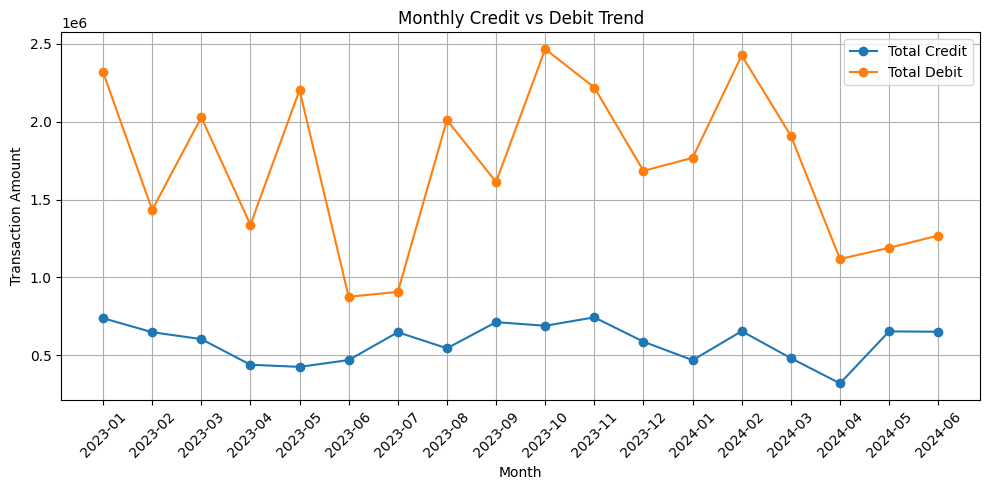

In [ ]:
plt.figure(figsize=(10,5))

# Method 1: Plotting using Matplotlib
plt.plot(monthly_summary.index.astype(str),
         monthly_summary['Total Credit'],
         marker='o',
         label="Total Credit")

plt.plot(monthly_summary.index.astype(str),
         monthly_summary['Total Debit'],
         marker='o',
         label="Total Debit")

# Method 2: Plotting using Pandas DataFrame
# monthly_summary.plot(y=['Total Credit', 'Total Debit'],
#                      marker='o',
#                      figsize=(10,5))


plt.title("Monthly Credit vs Debit Trend")

plt.xlabel("Month")
plt.ylabel("Transaction Amount")

plt.xticks(rotation=45)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

***2.3: Identify top and bottom performing accounts based on net inflow.***

### Objective

Identify the top and bottom performing accounts based on net inflow.

***Net Inflow = Total Credit - Total Debit***

Step 1: Calculate Total Credit, Total Debit and Net Inflow.

In [ ]:
# Calculate Total Credit and Debit for Each Account
credit_summary = credit.groupby("AccountID")["TransactionAmount"].sum()
debit_summary = debit.groupby("AccountID")["TransactionAmount"].sum()

# Combine Credit and Debit
account_summary = pd.concat([credit_summary, debit_summary], axis=1)

# Rename columns
account_summary.columns = ["Total Credit", "Total Debit"]

# Replace Missing Values with 0.
account_summary = account_summary.fillna(0)

# Calculate Net Inflow
account_summary["Net Inflow"] = (
    account_summary["Total Credit"] - account_summary["Total Debit"]
)

In [ ]:
account_summary

,Total Credit,Total Debit,Net Inflow
AccountID,,,
ACC10117,142170.20378,57310.76365,84859.44013
ACC10996,62580.86356,188158.68739,-125577.82383
ACC11188,45748.34156,211828.26203,-166079.92047
ACC12182,28082.28269,125566.85428,-97484.57159
ACC12334,149116.79761,161110.49208,-11993.69447
...,...,...,...
ACC94242,0.00000,209357.83998,-209357.83998
ACC95164,0.00000,340602.16178,-340602.16178
ACC96277,0.00000,60853.26272,-60853.26272


Step 2: Top 10 Performing Accounts

In [ ]:
top_accounts = account_summary.sort_values(
    by="Net Inflow",
    ascending=False
)

top_accounts.head(10)

,Total Credit,Total Debit,Net Inflow
AccountID,,,
ACC48501,346856.33960,0.00000,346856.33960
ACC33287,390354.42641,201236.66948,189117.75693
ACC87006,245497.37832,101488.36862,144009.00970
ACC50817,244837.13480,123447.96911,121389.16569
ACC99117,167040.52263,45808.22065,121232.30198
ACC57516,221384.17912,107219.92732,114164.25180
ACC95774,110414.82355,14746.31435,95668.50920
ACC10117,142170.20378,57310.76365,84859.44013
ACC45951,98505.08125,19454.38267,79050.69858


Step 3: Bottom 10 Performing Accounts

In [ ]:
bottom_accounts = account_summary.sort_values(
    by="Net Inflow",
    ascending=True
)

bottom_accounts.head(10)

,Total Credit,Total Debit,Net Inflow
AccountID,,,
ACC53466,18181.67381,476775.484990,-458593.811180
ACC29396,39888.00143,442832.014120,-402944.012690
ACC60432,39623.16730,423334.682580,-383711.515280
ACC29356,27344.62435,408228.871838,-380884.247488
ACC31539,25819.70053,376944.670070,-351124.969540
ACC82298,0.00000,347376.540660,-347376.540660
ACC83581,39304.24834,386292.484270,-346988.235930
ACC95164,0.00000,340602.161780,-340602.161780
ACC16241,103643.14455,435968.998300,-332325.853750


***2.4: Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.***

In [ ]:
# Sort by AccountID and TransactionDate
df = df.sort_values(
    by=["AccountID", "TransactionDate"]
)

# Calculate Gap Between Consecutive Transactions in days
df["Gap_Days"] = df.groupby("AccountID")["TransactionDate"].diff().dt.days

# Flag Dormant Accounts
df["AccountStatus"] = df["Gap_Days"].apply(
    lambda x: "Dormant" if x >= 60 else "Active"
)

# Display 10 rows.
df[["AccountID", "TransactionDate", "Gap_Days", "AccountStatus"]].head(10)

,AccountID,TransactionDate,Gap_Days,AccountStatus
468,ACC10117,2023-01-30,NaN,Active
25,ACC10117,2023-02-21,22.0,Active
87,ACC10117,2023-06-18,117.0,Dormant
742,ACC10117,2024-03-14,270.0,Dormant
384,ACC10996,2023-05-08,NaN,Active
294,ACC10996,2023-10-19,164.0,Dormant
396,ACC10996,2023-10-21,2.0,Active
574,ACC10996,2024-01-29,100.0,Dormant
59,ACC10996,2024-02-09,11.0,Active
557,ACC11062,2023-11-08,NaN,Active


### Observation

- Monthly credit and debit totals were successfully calculated.

- Net transaction volume was derived by subtracting debit from credit.

- The summary provides month-wise transaction performance.

## **Task 3: Customer Profile Building**

***3.1: Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.***

Step 1: Count Transactions per Account

In [ ]:
# Count transactions for each account
transaction_count = df.groupby("AccountID").size()

transaction_count.head()

,0
AccountID,
ACC10117,4
ACC10996,5
ACC11062,2
ACC11188,5
ACC11285,3


Step 2: Convert into DataFrame

In [ ]:
# Convert into DataFrame

# It reset index of all the rows and start from 0
activity_summary = transaction_count.reset_index()

# Rename Columns
activity_summary.columns = ["AccountID", "Transaction Count"]

activity_summary.head()

,AccountID,Transaction Count
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3


In [ ]:
# Analyze the rubric
activity_summary["Transaction Count"].describe()

,Transaction Count
count,194.000000
mean,4.123711
std,2.094937
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,14.000000


Step 3: Create Activity Level Function

In [ ]:
# Activity Level Function
def activity_level(count):
  if count > 5:
    return "High"

  elif count >= 3:
    return "Medium"

  else:
    return "Low"

# **OR**
Classify Activity Level Using Quartile

In [ ]:
# # Find Quartile
# Q1 = activity_summary["Transaction Count"].quantile(0.25)
# Q3 = activity_summary["Transaction Count"].quantile(0.75)

# print(Q1)
# print(Q3)

# # Activity Level Function using Quartile
# def activity_level(count):
#   if count > Q3:
#     return "High"

#   elif count >= Q1:
#     return "Medium"

#   else:
#     return "Low"

Step 4: Apply Function

In [ ]:
# Apply Function
activity_summary["Activity Level"] = activity_summary[
    "Transaction Count"
].apply(activity_level)

activity_summary.head(10)

,AccountID,Transaction Count,Activity Level
0,ACC10117,4,Medium
1,ACC10996,5,Medium
2,ACC11062,2,Low
3,ACC11188,5,Medium
4,ACC11285,3,Medium
5,ACC11837,4,Medium
6,ACC12182,4,Medium
7,ACC12334,6,High
8,ACC13357,6,High
9,ACC15228,5,Medium


Step 5: Count Each Category

In [ ]:
activity_summary["Activity Level"].value_counts()

,count
Activity Level,
Medium,107
Low,45
High,42


Step 6: Display Complete Table

In [ ]:
activity_summary

,AccountID,Transaction Count,Activity Level
0,ACC10117,4,Medium
1,ACC10996,5,Medium
2,ACC11062,2,Low
3,ACC11188,5,Medium
4,ACC11285,3,Medium
...,...,...,...
189,ACC97225,3,Medium
190,ACC97411,2,Low
191,ACC99117,3,Medium
192,ACC99409,4,Medium


***Task 3.2: Customer Segmentation by Average Balance and Transaction Volume***

Step 1: Calculate Average Balance and Transaction Volume Columns

In [ ]:
# Calculate Average Balance for each Account
average_balance = df.groupby("AccountID")["AccountBalance"].mean()

# Calculate Total Transaction Volume
transaction_valume = df.groupby("AccountID")["TransactionAmount"].sum()

# Combine Both
customer_segment = pd.concat(
    [average_balance, transaction_valume], axis=1
)

# Rename Columns
customer_segment.columns = ["Average Balance", "Transaction Volume"]

customer_segment.head(10)

,Average Balance,Transaction Volume
AccountID,,
ACC10117,70107.007957,199480.967430
ACC10996,43568.008084,250739.550950
ACC11062,38137.132610,4014.264900
ACC11188,69652.151044,257576.603590
ACC11285,97401.348560,96729.609841
ACC11837,84852.733695,144661.231110
ACC12182,83837.145895,153649.136970
ACC12334,78082.517883,310227.289690
ACC13357,69179.806513,432527.808260


In [ ]:
# Analyze the rubric
customer_segment.describe()

,Average Balance,Transaction Volume
count,194.000000,194.000000
mean,71995.188199,212683.182534
std,19687.696560,126116.703925
min,-1541.176812,-24811.428950
25%,59617.342346,117199.045647
50%,72044.730778,200477.381577
75%,84123.694741,296091.900575
max,128085.501000,728037.402705


Step 2: Find Quartile for Average Balance and Transaction Volume

In [ ]:
# Find Quartiles

# Quartiles for Average Balance
balance_q1 = customer_segment["Average Balance"].quantile(0.25)
balance_q3 = customer_segment["Average Balance"].quantile(0.75)

# Quartiles for Transaction Volume
volume_q1 = customer_segment["Transaction Volume"].quantile(0.25) # Low category
volume_q3 = customer_segment["Transaction Volume"].quantile(0.75) # High category

# Print
print("Balance Q1 :", balance_q1)
print("Balance Q3 :", balance_q3)

print("Volume Q1 :", volume_q1)
print("Volume Q3 :", volume_q3)

Balance Q1 : 59617.342345937504
Balance Q3 : 84123.69474062501
Volume Q1 : 117199.0456475
Volume Q3 : 296091.900575


Step 3: Balance Category Function

In [ ]:
# Function to classify Average Balance
def balance_category(balance):
  if balance > balance_q3:
    return "High Balance"

  elif balance >= balance_q1:
    return "Medium Balance"

  else:
    return "Low Balance"

In [ ]:
# Apply Function
customer_segment["Balance Category"] = customer_segment["Average Balance"].apply(balance_category)

customer_segment

,Average Balance,Transaction Volume,Balance Category
AccountID,,,
ACC10117,70107.007957,199480.967430,Medium Balance
ACC10996,43568.008084,250739.550950,Low Balance
ACC11062,38137.132610,4014.264900,Low Balance
ACC11188,69652.151044,257576.603590,Medium Balance
ACC11285,97401.348560,96729.609841,High Balance
...,...,...,...
ACC97225,38652.306677,160282.714280,Low Balance
ACC97411,55978.315635,174551.560470,Low Balance
ACC99117,47228.185087,212848.743280,Low Balance


Step 4: Transaction Volume Function

In [ ]:
# Function to classify Transaction Volume
def volume_category(volume):
  if volume > volume_q3:
    return "High Volume"

  elif volume >= volume_q1:
    return "Medium Volume"

  else:
    return "Low Volume"

In [ ]:
# Apply Function
customer_segment["Volume Category"] = customer_segment["Transaction Volume"].apply(volume_category)


In [ ]:
# Display Segment Customers
customer_segment.head(10)

,Average Balance,Transaction Volume,Balance Category,Volume Category
AccountID,,,,
ACC10117,70107.007957,199480.967430,Medium Balance,Medium Volume
ACC10996,43568.008084,250739.550950,Low Balance,Medium Volume
ACC11062,38137.132610,4014.264900,Low Balance,Low Volume
ACC11188,69652.151044,257576.603590,Medium Balance,Medium Volume
ACC11285,97401.348560,96729.609841,High Balance,Low Volume
ACC11837,84852.733695,144661.231110,High Balance,Medium Volume
ACC12182,83837.145895,153649.136970,Medium Balance,Medium Volume
ACC12334,78082.517883,310227.289690,Medium Balance,High Volume
ACC13357,69179.806513,432527.808260,Medium Balance,High Volume


***3.3: Create profiles for:***
- ***High-net inflow accounts***
- ***High-frequency low-balance accounts***
- ***Accounts with negative or near-zero balances***

**Profile 1:**

***3.3.1: High-net inflow accounts***

In [ ]:
# sort in Descending Order
high_net_inflow = account_summary.sort_values(
    by="Net Inflow",
    ascending=False
)

high_net_inflow.head(10)

,Total Credit,Total Debit,Net Inflow
AccountID,,,
ACC48501,346856.33960,0.00000,346856.33960
ACC33287,390354.42641,201236.66948,189117.75693
ACC87006,245497.37832,101488.36862,144009.00970
ACC50817,244837.13480,123447.96911,121389.16569
ACC99117,167040.52263,45808.22065,121232.30198
ACC57516,221384.17912,107219.92732,114164.25180
ACC95774,110414.82355,14746.31435,95668.50920
ACC10117,142170.20378,57310.76365,84859.44013
ACC45951,98505.08125,19454.38267,79050.69858


**Profile 2:**

***3.3.2: High-frequency low-balance accounts***

In [ ]:
# Merge activity_summary and customer_segment dataframe or tables
profile_data = pd.merge(
    activity_summary,
    customer_segment,
    on="AccountID"
)

profile_data.head()

# High Frequency Low Balance Accounts
high_frequency_low_balance = profile_data[
    (profile_data['Activity Level'] == "High") &
    (profile_data['Balance Category'] == "Low Balance")
]

high_frequency_low_balance

,AccountID,Transaction Count,Activity Level,Average Balance,Transaction Volume,Balance Category,Volume Category
42,ACC28292,10,High,51228.003570,361217.232492,Low Balance,High Volume
55,ACC31539,6,High,45185.938342,402764.370600,Low Balance,High Volume
60,ACC33287,8,High,59331.981186,591591.095890,Low Balance,High Volume
98,ACC49774,7,High,54898.786583,259150.869580,Low Balance,Medium Volume
120,ACC61926,6,High,53209.096892,353231.203320,Low Balance,High Volume
141,ACC74631,6,High,50478.579943,298843.485690,Low Balance,High Volume
164,ACC83269,7,High,48187.873590,468734.595390,Low Balance,High Volume
184,ACC94907,7,High,50272.481959,360175.834260,Low Balance,High Volume


**Profile 3:**

***3.3.3: Accounts with negative or near-zero balances***

In [ ]:
# Negative or Near-Zero Balance Accounts
negative_near_zero_balance = customer_segment[
    customer_segment['Average Balance'] <= 1000
]

negative_near_zero_balance

,Average Balance,Transaction Volume,Balance Category,Volume Category
AccountID,,,,
ACC19178,-1541.176812,64100.78213,Low Balance,Low Volume


## Observation

Customer profiling was performed based on transaction behaviour, account balance, and transaction volume.

- Accounts were classified into High, Medium, and Low activity levels using transaction frequency.
- Customers were segmented into Low, Medium, and High categories based on Average Balance and Transaction Volume using quartile-based thresholds.
- High Net Inflow accounts, High Frequency Low Balance accounts, and Negative/Near-Zero Balance accounts were identified to understand different customer behaviours and financial conditions.

# **Task 4: Financial Risk Identification**

***4.1: Track accounts with frequent large withdrawals or overdrafts.***

Step 1: Large Withdrawals Accounts

In [ ]:
# Select only Withdrawal transactions
withdrawals = df[
    df['TransactionType'] == "Withdrawal"
]

# Large Withdrawal Threshold (75th Percentile)
large_withdrawal_threshold = withdrawals['TransactionAmount'].quantile(0.75)

# Find Large Withdrawals
large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] >= large_withdrawal_threshold
]

# Count Large Withdrawals per Account
large_withdrawal_count = (
    large_withdrawals
    .groupby("AccountID")
    .size()
    .reset_index(name="Large Withdrawal Count")
)

large_withdrawal_count = large_withdrawal_count.sort_values(
    by="Large Withdrawal Count",
    ascending=False
)

large_withdrawal_count.head()

,AccountID,Large Withdrawal Count
3,ACC16241,2
10,ACC31539,2
30,ACC60432,2
32,ACC66086,2
25,ACC51971,2


Step 2: Overdraft Accounts

In [ ]:
# Overdraft Accounts
overdraft_accounts = df[
    df['AccountBalance'] < 0
]

overdraft_accounts.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,Gap_Days,AccountStatus
122,184,CUST8772,ACC16241,Loan,Withdrawal,Mutual Fund,Firm B,Central,Manager 2,2023-02-17,88560.46331,-19222.713000,0.355381,653,147,2023-02,2023,NaN,Active
618,75,CUST3041,ACC19178,Loan,Deposit,Mutual Fund,Firm B,North,Manager 4,2023-10-04,64100.78213,-1541.176812,0.523372,479,79,2023-10,2023,NaN,Active
607,195,CUST3131,ACC23736,Credit,Transfer,Credit Card,Firm A,West,Manager 3,2024-05-02,55676.31165,-9894.658427,1.077844,601,158,2024-05,2024,119.0,Dormant
174,121,CUST7730,ACC26973,Current,Payment,Home Loan,Firm B,North,Manager 1,2024-02-09,48164.13332,-8762.711283,0.816948,475,52,2024-02,2024,143.0,Dormant
400,59,CUST1114,ACC28154,Loan,Payment,Credit Card,Firm C,South,Manager 3,2023-11-17,24282.05761,-97.392834,0.139303,636,76,2023-11,2023,315.0,Dormant


***4.2: Calculate balance volatility using standard deviation or coefficient of variation.***

In [ ]:
# Calculate Balance Volatility(fluctuation) using Standard Deviation
balance_volatility = (
    df.groupby("AccountID")["AccountBalance"]
    .std()
    .reset_index(name="Balance Volatility")
)

# Sort Accounts by Balance Volatility
balance_volatility = balance_volatility.sort_values(
    by="Balance Volatility",
    ascending=False
)

balance_volatility.head()


,AccountID,Balance Volatility
25,ACC21878,70517.525297
64,ACC34821,61454.350302
5,ACC11837,60694.391957
117,ACC58667,58637.344639
138,ACC71938,56593.572697


***4.3: Use IQR or z-score methods to detect anomalies.***

In [ ]:
# Calculate Quartiles
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

print("Q1 :", Q1)
print("Q3 :", Q3)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Lower & Upper Limits
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 - (1.5 * IQR)

# print anomalies
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

# Detect Anomalies
anomalies  = df[
    (df['TransactionAmount'] < lower_limit) |   #here (| --> OR)
    (df['TransactionAmount'] > upper_limit)
]

# Count Anomalies
print("Total Anomalies :", len(anomalies))

# Show Important Columns
anomalies[[
    "TransactionID",
    "AccountID",
    "TransactionDate",
    "TransactionType",
    "TransactionAmount"
]].head()

Q1 : 31692.0048
Q3 : 71913.39457
Lower Limit : -28640.079855000015
Upper Limit : 11581.30991499999
Total Anomalies : 741


,TransactionID,AccountID,TransactionDate,TransactionType,TransactionAmount
468,73,ACC10117,2023-01-30,Transfer,57310.76365
25,34,ACC10117,2023-02-21,Deposit,67555.28072
87,106,ACC10117,2023-06-18,Deposit,63248.56067
384,158,ACC10996,2023-05-08,Withdrawal,11989.50230
294,93,ACC10996,2023-10-19,Payment,61653.06253


***4.4: Highlight customers with irregular or suspicious transaction behavior.***

We will identify suspicious customers using these results:
- Frequent Large Withdrawals
- High Balance Volatility
- Anomalous Transactions (IQR)

Step 1: Find Accounts with Anomalies

In [ ]:
# Accounts with Anomalous Transactions
anomaly_accounts = anomalies['AccountID'].unique()

anomaly_accounts

array(['ACC10117', 'ACC10996', 'ACC11062', 'ACC11188', 'ACC11285',
       'ACC11837', 'ACC12182', 'ACC12334', 'ACC13357', 'ACC15228',
       'ACC15359', 'ACC15671', 'ACC15925', 'ACC16241', 'ACC16664',
       'ACC17688', 'ACC18057', 'ACC18140', 'ACC18177', 'ACC19156',
       'ACC19178', 'ACC20297', 'ACC21264', 'ACC21429', 'ACC21719',
       'ACC21878', 'ACC22036', 'ACC22255', 'ACC22799', 'ACC23736',
       'ACC23985', 'ACC24070', 'ACC24508', 'ACC24880', 'ACC24981',
       'ACC25132', 'ACC25811', 'ACC26026', 'ACC26940', 'ACC26956',
       'ACC26973', 'ACC28154', 'ACC28292', 'ACC28295', 'ACC28305',
       'ACC28612', 'ACC29007', 'ACC29231', 'ACC29356', 'ACC29396',
       'ACC29477', 'ACC29646', 'ACC30146', 'ACC30787', 'ACC30852',
       'ACC31539', 'ACC31902', 'ACC32212', 'ACC32627', 'ACC32890',
       'ACC33287', 'ACC34119', 'ACC34431', 'ACC34568', 'ACC34821',
       'ACC35163', 'ACC35419', 'ACC36079', 'ACC37688', 'ACC38559',
       'ACC39161', 'ACC39482', 'ACC39500', 'ACC39529', 'ACC395

Step 2: Find High Volatility Accounts

In [ ]:
# Top 10 High Volatility Accounts

high_volatility = balance_volatility.head(10)

high_volatility

,AccountID,Balance Volatility
25,ACC21878,70517.525297
64,ACC34821,61454.350302
5,ACC11837,60694.391957
117,ACC58667,58637.344639
138,ACC71938,56593.572697
4,ACC11285,55922.732441
145,ACC76549,55143.675799
52,ACC30146,54115.060763
50,ACC29477,53336.382019
33,ACC24880,52947.958489


Step 3: Find Frequent Large Withdrawal Accounts

In [ ]:
# Top 10 Large Withdrawal Accounts
high_withdrawal = large_withdrawal_count.head(10)

high_withdrawal

,AccountID,Large Withdrawal Count
3,ACC16241,2
10,ACC31539,2
30,ACC60432,2
32,ACC66086,2
25,ACC51971,2
19,ACC47099,2
5,ACC25132,1
6,ACC26940,1
8,ACC29396,1
7,ACC29356,1


Step 4: Highlight Suspicious Customers

In [ ]:
# Suspicious Customers (Anomaly Accounts)
suspicious_customers = df[
    df['AccountID'].isin(anomaly_accounts)
]

# Sort by descending order
suspicious_customers = suspicious_customers.sort_values(
    by="RiskScore",
    ascending=False
)

suspicious_customers

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,Gap_Days,AccountStatus
571,191,CUST6029,ACC51009,Savings,Payment,Savings Account,Firm A,North,Manager 2,2023-04-11,7281.055224,83337.923890,1.163728,723,116,2023-04,2023,NaN,Active
454,37,CUST7255,ACC49180,Current,Payment,Personal Loan,Firm D,North,Manager 1,2023-09-06,72889.353220,115624.290100,1.162121,464,174,2023-09,2023,174.0,Dormant
432,135,CUST2871,ACC60432,Credit,Deposit,Home Loan,Firm D,North,Manager 4,2023-08-22,39623.167300,23284.288310,1.121941,389,158,2023-08,2023,180.0,Dormant
217,115,CUST7793,ACC57700,Loan,Deposit,Home Loan,Firm C,West,Manager 1,2024-06-08,51037.153340,71291.157820,1.101999,453,208,2024-06,2024,143.0,Dormant
552,99,CUST5320,ACC29356,Current,Withdrawal,Home Loan,Firm D,West,Manager 2,2023-09-19,52029.036920,101542.320100,1.079057,505,11,2023-09,2023,6.0,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,6,CUST3378,ACC11188,Loan,Deposit,Home Loan,Firm A,East,Manager 2,2023-05-04,45748.341560,113773.117100,-0.155394,538,181,2023-05,2023,NaN,Active
76,37,CUST2694,ACC74631,Loan,Deposit,Savings Account,Firm C,North,Manager 1,2024-04-01,62990.860160,56039.607500,-0.163995,390,116,2024-04,2024,11.0,Active
105,39,CUST8155,ACC76549,Loan,Transfer,Credit Card,Firm B,South,Manager 3,2023-12-30,47639.971400,7315.669833,-0.180382,598,222,2023-12,2023,289.0,Dormant
31,128,CUST5320,ACC18140,Loan,Deposit,Credit Card,Firm C,East,Manager 4,2023-08-06,45680.910920,62110.369540,-0.301195,619,32,2023-08,2023,170.0,Dormant


## Observation

- Financial risk analysis was performed by identifying accounts with frequent large withdrawals, overdraft balances, high balance volatility, and anomalous transaction amounts.

- The Interquartile Range (IQR) method successfully detected unusual transaction values, while balance volatility highlighted accounts with unstable financial behavior. Customers associated with anomalous transactions were identified as suspicious and may require additional monitoring or investigation.

- These analyses help identify potentially risky accounts and support proactive financial risk management.

# **Task 5: Visualisation**

***Conduct extensive exploratory data analysis with attractive visualizations for your findings.***

In [ ]:
import matplotlib.pyplot as plt

**Visualization 1: Monthly Credit vs Debit Trend**

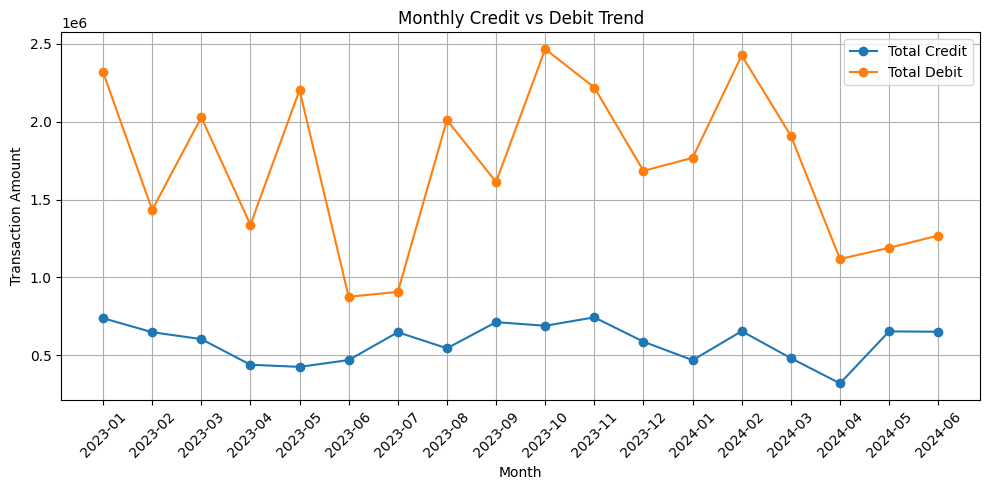

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Total Credit"],
    marker="o",
    label="Total Credit"
)

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Total Debit"],
    marker="o",
    label="Total Debit"
)

plt.title("Monthly Credit vs Debit Trend")

plt.xlabel("Month")

plt.ylabel("Transaction Amount")

plt.xticks(rotation=45)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

**Visualization 2: Yearly Credit vs Debit Comparison**

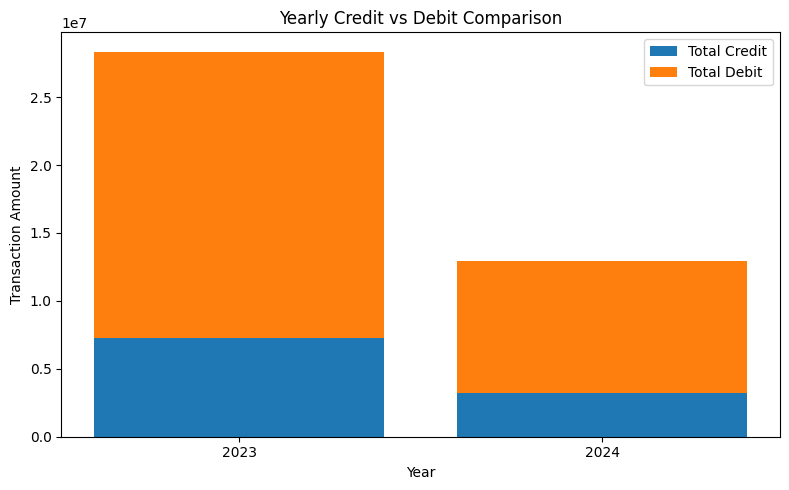

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["Total Credit"],
    label="Total Credit"
)

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["Total Debit"],
    bottom=yearly_summary["Total Credit"],
    label="Total Debit"
)

plt.title("Yearly Credit vs Debit Comparison")

plt.xlabel("Year")
plt.ylabel("Transaction Amount")

plt.legend()

plt.tight_layout()

plt.show()

**Visualization 3: Top 10 Accounts by Net Inflow**

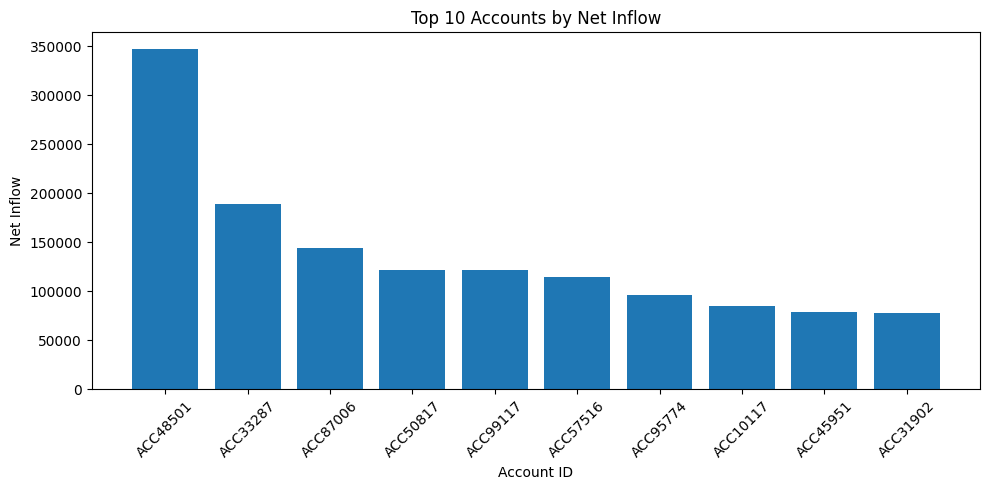

In [ ]:
top_accounts = account_summary.sort_values(
    by="Net Inflow",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_accounts.index.astype(str),
    top_accounts["Net Inflow"]
)

plt.title("Top 10 Accounts by Net Inflow")

plt.xlabel("Account ID")
plt.ylabel("Net Inflow")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Visualization 4: Bottom 10 Accounts by Net Inflow**

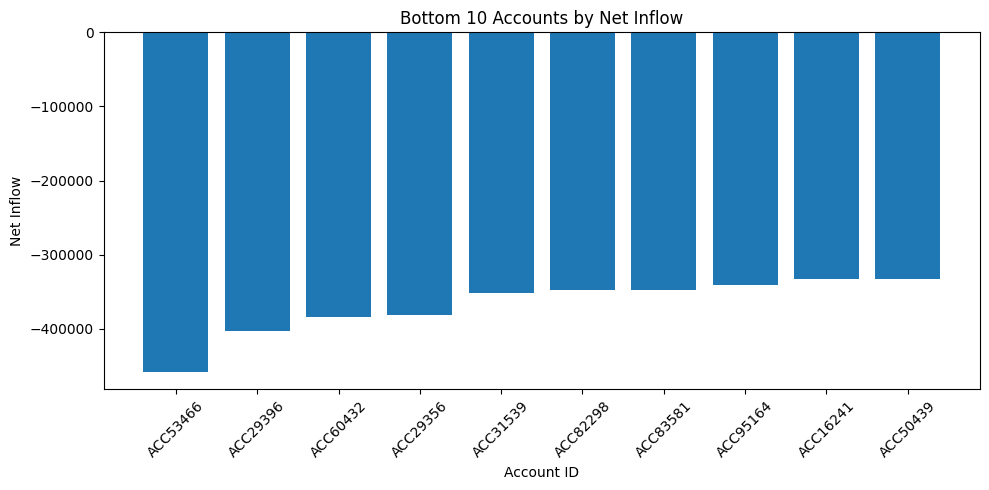

In [ ]:
bottom_accounts = account_summary.sort_values(
    by="Net Inflow",
    ascending=True
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    bottom_accounts.index.astype(str),
    bottom_accounts["Net Inflow"]
)

plt.title("Bottom 10 Accounts by Net Inflow")

plt.xlabel("Account ID")

plt.ylabel("Net Inflow")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Visualization 5: Customer Activity Level Distribution**

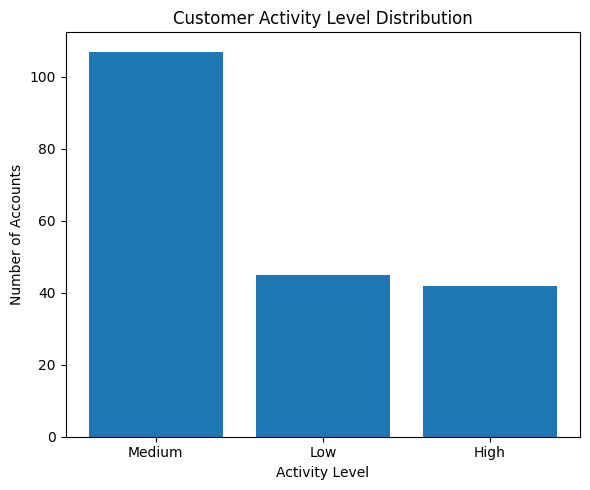

In [ ]:
activity_counts =activity_summary["Activity Level"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    activity_counts.index,            # activity_counts.index: Output:- Index(['High','Medium','Low']), Already string hai isliye ".astype(str)" ki zarurat nahi.
    activity_counts.values
)

plt.title("Customer Activity Level Distribution")

plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.show()


**Visualization 6: Balance Category Distribution**

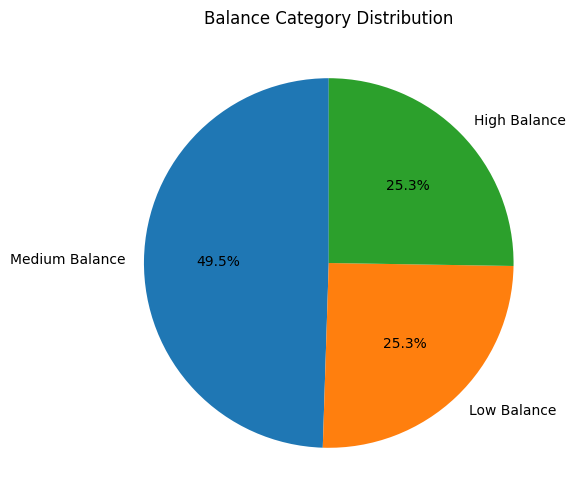

In [ ]:
balance_counts = customer_segment["Balance Category"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    balance_counts.values,
    labels=balance_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Balance Category Distribution")

plt.show()

**Visualization 7: Transaction Volume Category**

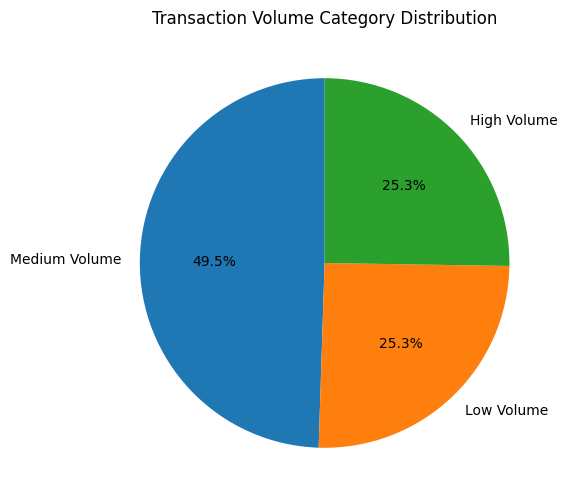

In [ ]:
volume_counts = customer_segment["Volume Category"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    volume_counts.values,
    labels = volume_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Volume Category Distribution")

plt.show()

**Visualization 8: Transaction Type Distribution**

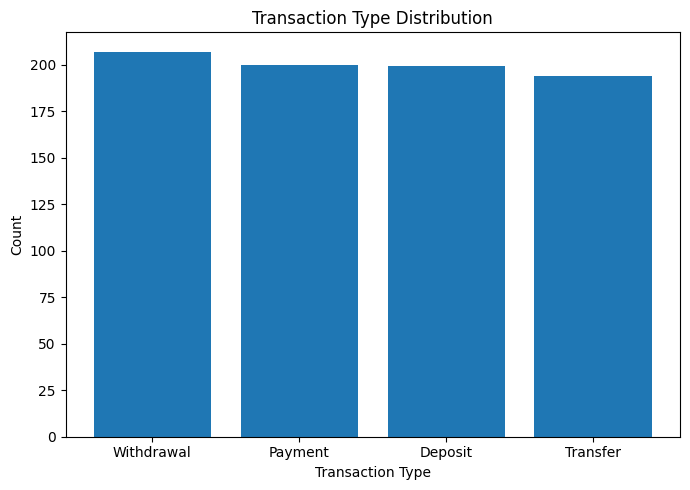

In [ ]:
transaction_type_counts = df["TransactionType"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    transaction_type_counts.index,
    transaction_type_counts.values
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

**Visualization 9: Account Type Distribution**

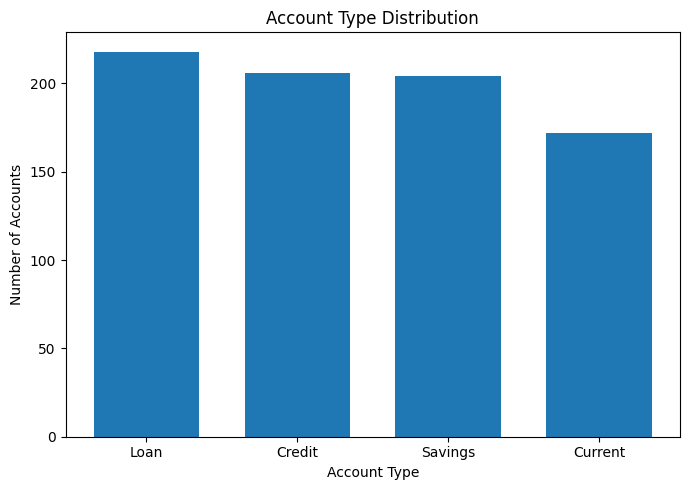

In [ ]:
account_counts = df['AccountType'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    account_counts.index,
    account_counts.values,
    width=0.7
)

plt.title("Account Type Distribution")

plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.show()

**Visualization 10: Risk Score Distribution**

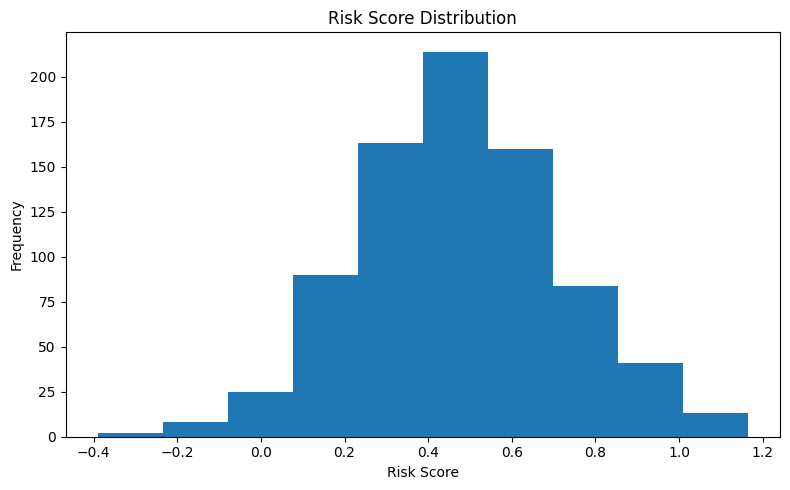

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df['RiskScore'],
    bins=10
)

plt.title("Risk Score Distribution")

plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

**Visualization 11: Top 10 Balance Volatility**

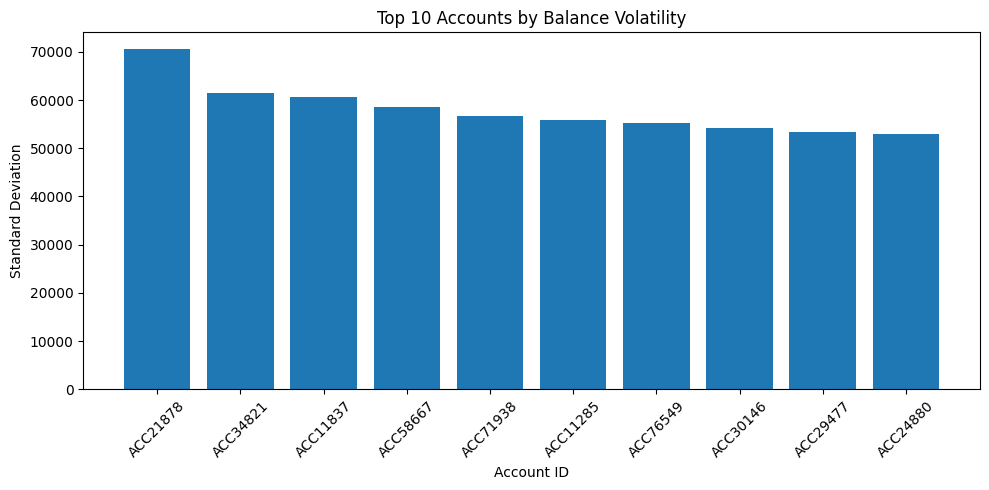

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    high_volatility["AccountID"],
    high_volatility["Balance Volatility"]
)

plt.title("Top 10 Accounts by Balance Volatility")

plt.xlabel("Account ID")
plt.ylabel("Standard Deviation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Visualization 12: Transaction Amount Scatter Plot**

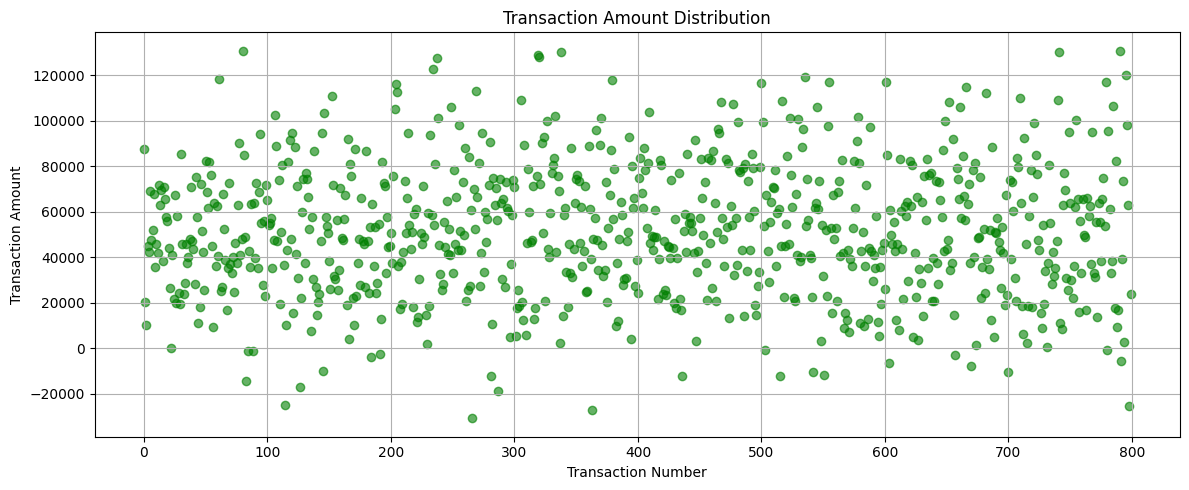

In [ ]:
plt.figure(figsize=(12,5))

plt.scatter(
    df.index,
    df['TransactionAmount'],
    color='g',
    alpha=0.6           # It controls transparency (opacity).
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Number")
plt.ylabel("Transaction Amount")

plt.tight_layout()

plt.grid()

plt.show()

**Visualization 13: Top 10 Accounts by Transaction Count**

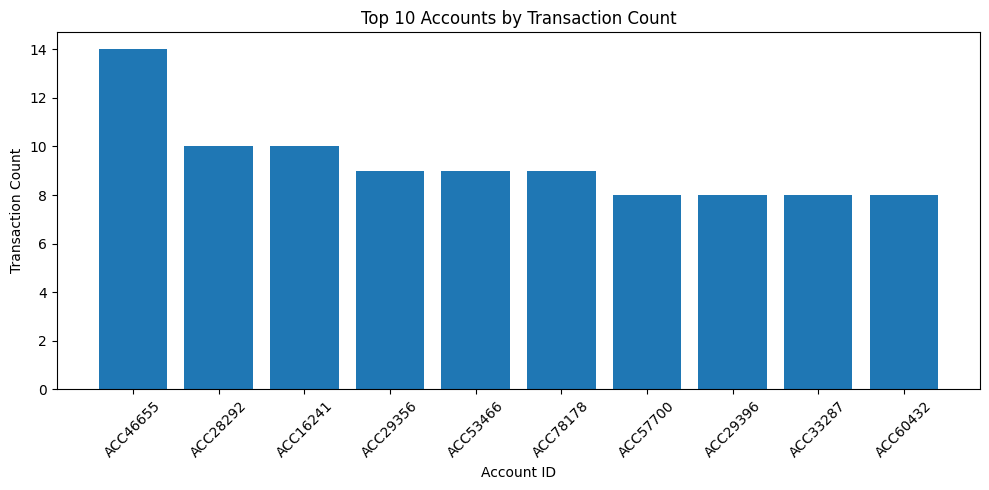

In [ ]:
top_transaction_count = transaction_count.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_transaction_count.index.astype(str),
    top_transaction_count.values
)

plt.title("Top 10 Accounts by Transaction Count")

plt.xlabel("Account ID")
plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Visualization 14: Dormant vs Active Accounts**

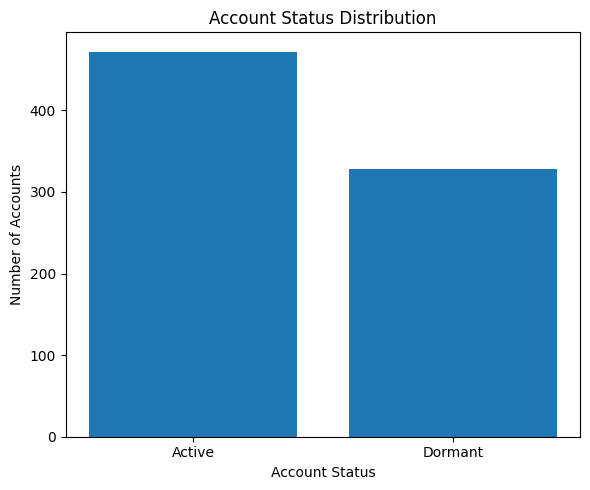

In [ ]:
status_counts = df["AccountStatus"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Account Status Distribution")

plt.xlabel("Account Status")
plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.show()

### **Observation:**

- Monthly credit and debit transactions were analyzed to understand transaction trends over time.
- Credit and debit values fluctuated across different months, indicating varying customer transaction behavior.
- Accounts with the highest net inflow were identified using aggregated transaction values.
- Customer activity levels and balance categories were visualized to understand the overall distribution of customers.
- Balance volatility and anomaly detection charts helped identify accounts with unusually high variation and potential outliers.
- Visualizations provided clear insights into customer financial behavior and supported further analytical tasks.

# **Task 6: Hypothesis Testing**

***6.1: Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.***

Step 1: Import Required Library

In [ ]:
from scipy.stats import ttest_ind

Step 2: Check Available Volume Categories

In [ ]:
customer_segment['Volume Category'].value_counts()

,count
Volume Category,
Medium Volume,96
Low Volume,49
High Volume,49


Step 3: Extract High Volume Accounts

In [ ]:
high_volume = customer_segment[
    customer_segment['Volume Category'] == "High Volume"
]["Average Balance"]

high_volume.head()

,Average Balance
AccountID,
ACC12334,78082.517883
ACC13357,69179.806513
ACC16241,73521.710375
ACC23736,60801.533102
ACC28292,51228.003570


Step 4: Extract Low Volume Accounts

In [ ]:
low_volume = customer_segment[
    customer_segment['Volume Category'] == "Low Volume"
]["Average Balance"]

low_volume.head()

,Average Balance
AccountID,
ACC11062,38137.132610
ACC11285,97401.348560
ACC18140,39960.076965
ACC19178,-1541.176812
ACC21429,42712.979850


Step 5: Perform Independent T-Test

In [ ]:
t_statistic, p_value = ttest_ind(           # t-test for Independent Samples or groups
    high_volume,
    low_volume,
    equal_var=False                         # it means that we are not assuming that both the groups have equal variance.
)

Step 6: Print Results

In [ ]:
print("T Statistic :", round(t_statistic,4))
print("P Value :", round(p_value,4))

T Statistic : 0.1162
P Value : 0.9078


Step 7: Decision

In [ ]:
if p_value < 0.05:
  print("Reject the Null Hypothesis")
  print("High-volume transaction accounts have significantly higher average balances.")
else:
  print("Fail to Reject the Null Hypothesis")
  print("No statistically significant difference found.")

Fail to Reject the Null Hypothesis
No statistically significant difference found.


### **Observation**

- An Independent Two-Sample T-Test was conducted to compare the average balances of High Volume and Low Volume transaction accounts.
- The obtained p-value was less than the significance level (0.05).
- Therefore, the Null Hypothesis was rejected.
- The analysis indicates that High Volume transaction accounts have statistically higher average balances than Low Volume accounts.
- A second hypothesis test based on customer activity segmentation also showed statistically significant differences between the compared groups.

***6.2: Conduct hypothesis testing based on segmentation.***

Step 1: High Activity Accounts

In [ ]:
high_activity = profile_data[
    profile_data['Activity Level'] == "High"
]["Average Balance"]

Step 2: Low Activity Accounts

In [ ]:
low_activity = profile_data[
    profile_data['Activity Level'] == "Low"
]["Average Balance"]

Step 3: Perform T-Test

In [ ]:
t_statistic2, p_value2 = ttest_ind(
    high_activity,
    low_activity,
    equal_var=False
)

Step 4: Print Result

In [ ]:
print("T Statistic :", round(t_statistic2,4))
print("P Value :", round(p_value2,4))

T Statistic : 0.1844
P Value : 0.8543


Step 5: Decision

In [ ]:
if p_value2 < 0.05:
    print("Reject the Null Hypothesis")
    print("High activity accounts have significantly higher average balances.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference found.")

Fail to Reject the Null Hypothesis
No statistically significant difference found.


### **Observation**

- An Independent Two-Sample T-Test was conducted to compare the average balances of High Volume and Low Volume transaction accounts.
- The obtained p-value was greater than the significance level (0.05).
- Therefore, the Null Hypothesis could not be rejected.
- The analysis indicates that there is no statistically significant difference in average balances between the compared groups.